# KKBox Churn Analysis - Cohort Retention Analysis

**Cohort analysis** groups customers by a shared characteristic (in this case, signup month) and tracks their behaviour over time.

**Why cohort analysis?**
- Reveals retention patterns by acquisition period
- Identifies seasonal effects (do summer signups churn faster?)
- Measures product improvements (are newer cohorts retained better?)
- Calculates cohort-specific lifetime value
- Detects data quality issues (missing cohorts, anomalies)

### What We'll Analyse

1. **Cohort Definition**
- Cohort = Month of first subscription
- Example: "Jan 2015 cohort" = all users who first subscribed in January 2015

2. **Retention Metrics**
- Month 0: % still subscribed in signup month (always 100%)
- Month 1: % still subscribed 1 month later
- Month 3: % still subscribed 3 months later
- Month 6, 12, 18...Long-term retention

3. **Key Questions**
- Which cohorts have the best/worst retention?
- How does retention change over time (improving/declining)?
- What's the typical retention curve shape?
- When does most churn happen (month 1? month 3?)


### Visualisations

1. **Cohort Retention Heatmap** - Classic retention table
2. **Retention Curves** - Line plots by cohort
3. **Month 1/3/6/12 Retention Comparison** - Bar charts
4. **Cohort Size Distribution** - How many users per cohort?
5. **Retention Rate Trends** - Are we improving over time?
6. **Churn Timing Analysis** - When do users drop off?

### Business Value

After this analysis, we can:
- Set retention benchmarks (e.g., "Target: 50% month-3 retention")
- Identify problem cohorts for investigation
- Measure product changes (did new feature improve retention?)
- Calculate LTV by cohort (revenue × retention curve)
- Forecast churn based on historical patterns

# Setup

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Step 1 - Load and Prepare Data


For cohort analysis, we need:
1. User ID** (`msno`)
2. First subscription date (cohort assignment)
3. Activity by month (to track retention)

**Data Source**

This notebook uses pre-processed subscription data from data prep. No need to process raw transactions as subscriptions are already clean!

In [2]:
# Load subscriptions data
subscriptions = pd.read_pickle('../notebooks/kkbox_subscriptions.pkl')

# Ensure dates are datetime
subscriptions['starts_at'] = pd.to_datetime(subscriptions['starts_at'])
subscriptions['ends_at'] = pd.to_datetime(subscriptions['ends_at'])

print(f"   Loaded {len(subscriptions):,} subscriptions")
print(f"   Date range: {subscriptions['starts_at'].min().date()} to {subscriptions['starts_at'].max().date()}")


   Loaded 3,131,727 subscriptions
   Date range: 2015-01-01 to 2017-03-31


In [3]:
# Assigning users to cohorts

# Get cohort = month of first subscription per user
user_cohorts = subscriptions.groupby('msno').agg({
    'starts_at': 'min'  # First subscription start = cohort
}).reset_index()

user_cohorts['cohort_month'] = user_cohorts['starts_at'].dt.to_period('M')
user_cohorts = user_cohorts[['msno', 'cohort_month']]

# Merge back to subscriptions
subscriptions = subscriptions.merge(user_cohorts, on='msno', how='left')

print(f"   Assigned {subscriptions['msno'].nunique():,} users to cohorts")
print(f"   Cohort range: {subscriptions['cohort_month'].min()} to {subscriptions['cohort_month'].max()}")

   Assigned 2,420,599 users to cohorts
   Cohort range: 2015-01 to 2017-03


## Step 2 - Calculate Cohort Retention

## The Cohort Retention Matrix

**Structure:**
```
Cohort      Month_0  Month_1  Month_2  Month_3  ...
2015-01     100%     65%      52%      45%      ...
2015-02     100%     68%      55%      48%      ...
2015-03     100%     62%      49%      42%      ...
```

**Rows:** Signup cohorts (month)

**Columns:** Months since signup (age)

**Values:** % of cohort still active

In [4]:
# Set observation parameters
observation_end = pd.Period('2017-04', 'M')   # Observation end date (from data prep)
print(f"   Observation end: {observation_end}")

# Maximum months to track
max_months_to_track = 24
print(f"   Tracking up to: {max_months_to_track} months per cohort")

   Observation end: 2017-04
   Tracking up to: 24 months per cohort


In [5]:
# Calculate retention by cohort and month

retention_data = []
cohorts = sorted(subscriptions['cohort_month'].dropna().unique())

for idx, cohort in enumerate(cohorts):
    if idx % 10 == 0:
        print(f"   Processing cohort {idx+1}/{len(cohorts)}: {cohort}...", end='\r')
    
    # Get all users in this cohort
    cohort_users = subscriptions[subscriptions['cohort_month'] == cohort]['msno'].unique()
    cohort_size = len(cohort_users)
    
    # Skip tiny cohorts
    if cohort_size < 10:
        continue
    
    # Calculate how many months we can track for this cohort
    max_age = min(max_months_to_track, (observation_end - cohort).n + 1)
    
    # For each month offset (0, 1, 2, ..., max_age-1)
    for month_offset in range(max_age):
        target_month = cohort + month_offset
        
        # Count users with active subscription in target month
        # Active = subscription start <= target_month AND (end >= target_month OR end is NULL)
        active_subs = subscriptions[
            (subscriptions['msno'].isin(cohort_users)) &
            (subscriptions['starts_at'].dt.to_period('M') <= target_month)
        ]
        
        # Check if subscription covers target month
        if month_offset == 0:
            # Month 0: all cohort users are active by definition
            active_users = cohort_size
        else:
            active_users = active_subs[
                (active_subs['ends_at'].dt.to_period('M') >= target_month) |
                (active_subs['ends_at'].isna())
            ]['msno'].nunique()
        
        retention_pct = (active_users / cohort_size * 100) if cohort_size > 0 else 0
        
        retention_data.append({
            'cohort_month': str(cohort),
            'month_offset': month_offset,
            'cohort_size': cohort_size,
            'active_users': active_users,
            'retention_pct': retention_pct
        })


print(f"\n\n   Calculated retention for {len(cohorts)} cohorts")

   Processing cohort 21/27: 2016-09...

   Calculated retention for 27 cohorts


In [6]:
# Create cohort retention matrix
retention_df = pd.DataFrame(retention_data)   # Convert to DataFrame

# Pivot to matrix format
cohort_retention = retention_df.pivot(
    index='cohort_month',
    columns='month_offset',
    values='retention_pct'
)

# Also create cohort sizes for reference
cohort_sizes = retention_df[retention_df['month_offset'] == 0].set_index('cohort_month')['cohort_size']

print(f"\n   Cohort retention matrix: {cohort_retention.shape}")
print(f"     Cohorts: {cohort_retention.shape[0]}")
print(f"     Months tracked: {cohort_retention.shape[1]}")

print("\n Cohort retention calculation complete")

print("\n Sample retention (first 10 cohorts, first 12 months):")
print(cohort_retention.iloc[:10, :12])



   Cohort retention matrix: (27, 24)
     Cohorts: 27
     Months tracked: 24

 Cohort retention calculation complete

 Sample retention (first 10 cohorts, first 12 months):
month_offset     0          1          2          3          4          5   \
cohort_month                                                                 
2015-01       100.0  97.075383  94.186639  91.764967  87.989060  87.172913   
2015-02       100.0  90.812237  77.382465  68.175154  71.848304  68.896491   
2015-03       100.0  96.066615  71.232542  71.366912  67.863105  66.199764   
2015-04       100.0  96.436177  73.447081  68.597819  65.524054  62.688903   
2015-05       100.0  92.762153  64.087554  60.906083  59.022652  56.696997   
2015-06       100.0  25.800495  20.656194  20.242411  19.228616  18.961828   
2015-07       100.0  97.378479  74.247879  65.631591  69.388629  68.381572   
2015-08       100.0  97.387974  63.230713  65.102418  63.172728  61.329342   
2015-09       100.0  97.667151  64.694756  62

# Step 3 - Cohort Size Analysis

Before analyzing retention, let's understand cohort sizes - how many users signed up each month?

In [ ]:
# Get cohort sizes (month 0 = all users in cohort)
cohort_sizes = retention_df[retention_df['month_offset'] == 0].set_index('cohort_month')['cohort_size']
cohort_sizes.index = cohort_sizes.index.astype(str)

print(f"\nTotal cohorts: {len(cohort_sizes)}")
print(f"Total users: {cohort_sizes.sum():,.0f}")

print(f"\nCohort size statistics:")
print(f"  Mean: {cohort_sizes.mean():,.0f} users/month")
print(f"  Median: {cohort_sizes.median():,.0f} users/month")
print(f"  Min: {cohort_sizes.min():,.0f} users")
print(f"  Max: {cohort_sizes.max():,.0f} users")

print("\nTop 10 largest cohorts:")
print(cohort_sizes.nlargest(10))

print("\nBottom 10 smallest cohorts:")
print(cohort_sizes.nsmallest(10))


Total cohorts: 27
Total users: 2,420,599

Cohort size statistics:
  Mean: 89,652 users/month
  Median: 64,710 users/month
  Min: 31,432 users
  Max: 549,166 users

Top 10 largest cohorts:
cohort_month
2015-01    549166
2015-06    191163
2015-11    163223
2016-11    145671
2016-10     98973
2015-12     96889
2016-01     89032
2015-10     87988
2015-08     74157
2015-09     72958
Name: cohort_size, dtype: int64

Bottom 10 smallest cohorts:
cohort_month
2015-05    31432
2017-03    34497
2017-02    37091
2017-01    38366
2016-04    38950
2015-04    38975
2016-12    41930
2016-05    43259
2015-03    49118
2015-02    51155
Name: cohort_size, dtype: int64


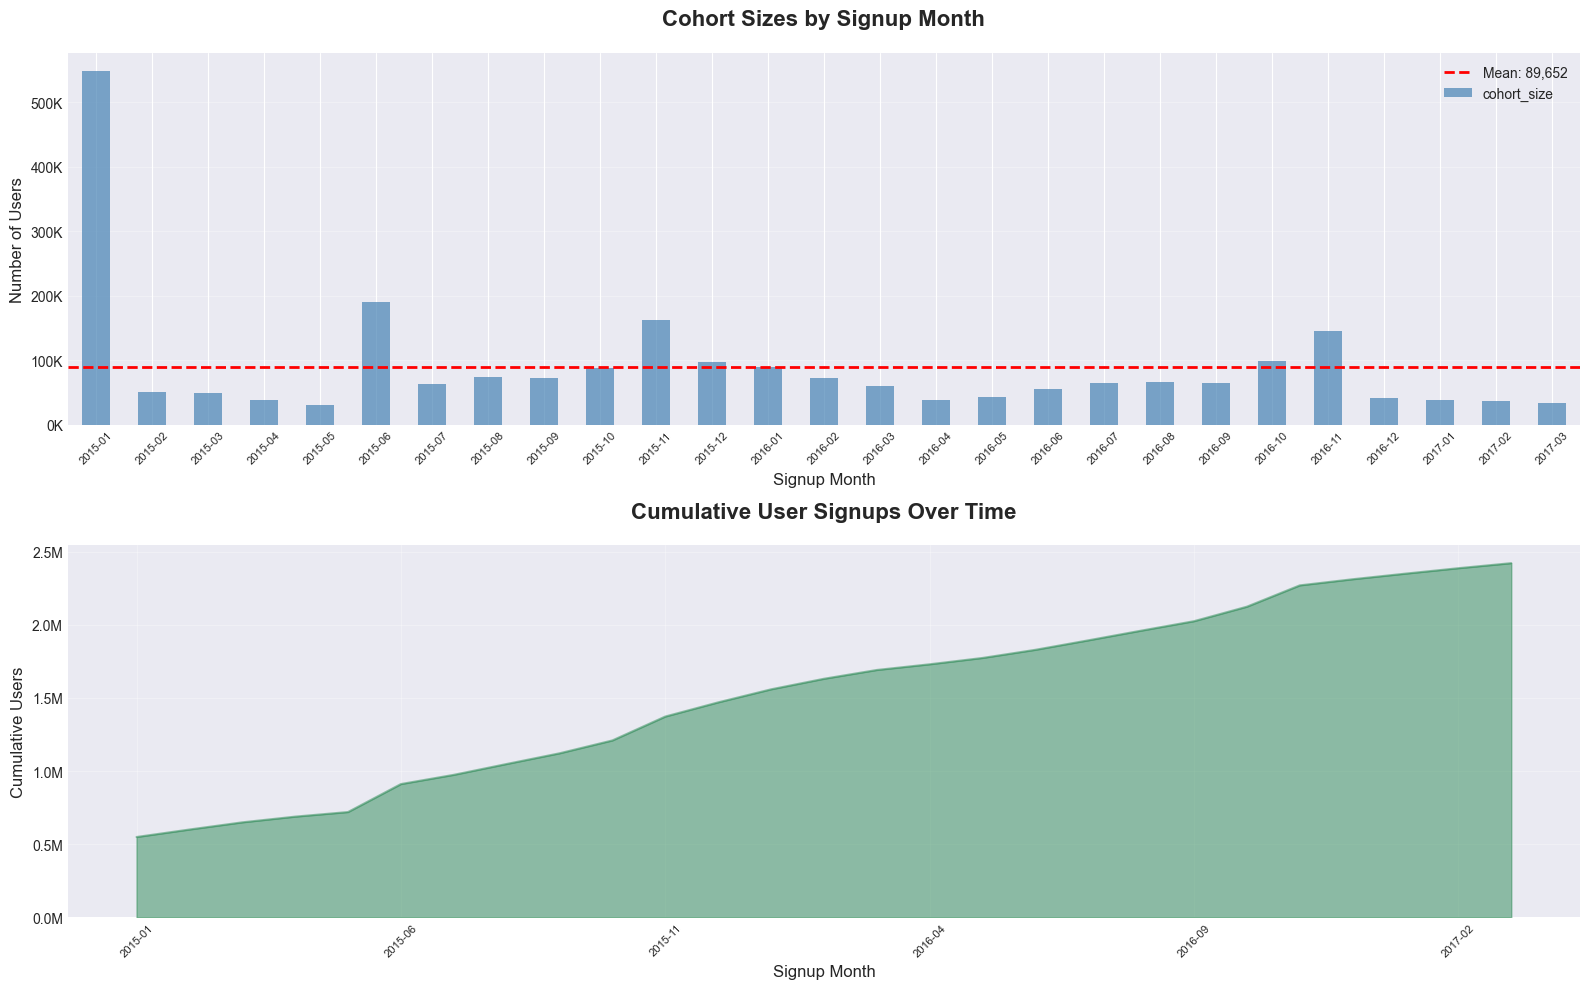


 Visualization saved: cohort_sizes.png


In [14]:
# Visualise cohort sizes

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot cohort sizes over time
ax1 = axes[0]
cohort_sizes.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.7)
ax1.set_title('Cohort Sizes by Signup Month', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Signup Month', fontsize=12)
ax1.set_ylabel('Number of Users', fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.grid(axis='y', alpha=0.3)

# Add horizontal line for mean
ax1.axhline(cohort_sizes.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {cohort_sizes.mean():,.0f}')
ax1.legend()

# Format y-axis
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# Plot cumulative signups
ax2 = axes[1]
cumulative_users = cohort_sizes.cumsum()
cumulative_users.plot(kind='area', ax=ax2, color='seagreen', alpha=0.5)
ax2.set_title('Cumulative User Signups Over Time', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Signup Month', fontsize=12)
ax2.set_ylabel('Cumulative Users', fontsize=12)
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.grid(alpha=0.3)

# Format y-axis
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000000:.1f}M'))

plt.tight_layout()
plt.savefig('cohort_sizes.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualization saved: cohort_sizes.png")

## Step 4 - Cohort Retention Heatmap

Heatmap showing retention % for each cohort at each age.

**Color coding:**
- 🟩 Green: High retention (good)
- 🟨 Yellow: Medium retention
- 🟥 Red: Low retention (problem)

**How to read this heatmap:**

- Each row = one signup cohort
- Each column = months since signup
- Color = retention % (green=high, red=low)
- Month 0 always 100% (everyone starts active)
- Follow a row right → see that cohort's retention curve
- Follow a column down → compare Month-N retention across cohorts

In [15]:
# Focus on cohorts with at least 1,000 users (statistical significance)
min_cohort_size = 1000
significant_cohorts = cohort_sizes[cohort_sizes >= min_cohort_size].index

print(f"   Cohorts with ≥{min_cohort_size:,} users: {len(significant_cohorts)}")

# Filter retention matrix
cohort_retention_filtered = cohort_retention.loc[significant_cohorts].copy()

# Also limit to first 24 months (for readability)
max_age = min(24, cohort_retention_filtered.shape[1])
cohort_retention_filtered = cohort_retention_filtered.iloc[:, :max_age]

print(f"   Filtered matrix: {cohort_retention_filtered.shape[0]} cohorts × {cohort_retention_filtered.shape[1]} months")

   Cohorts with ≥1,000 users: 27
   Filtered matrix: 27 cohorts × 24 months


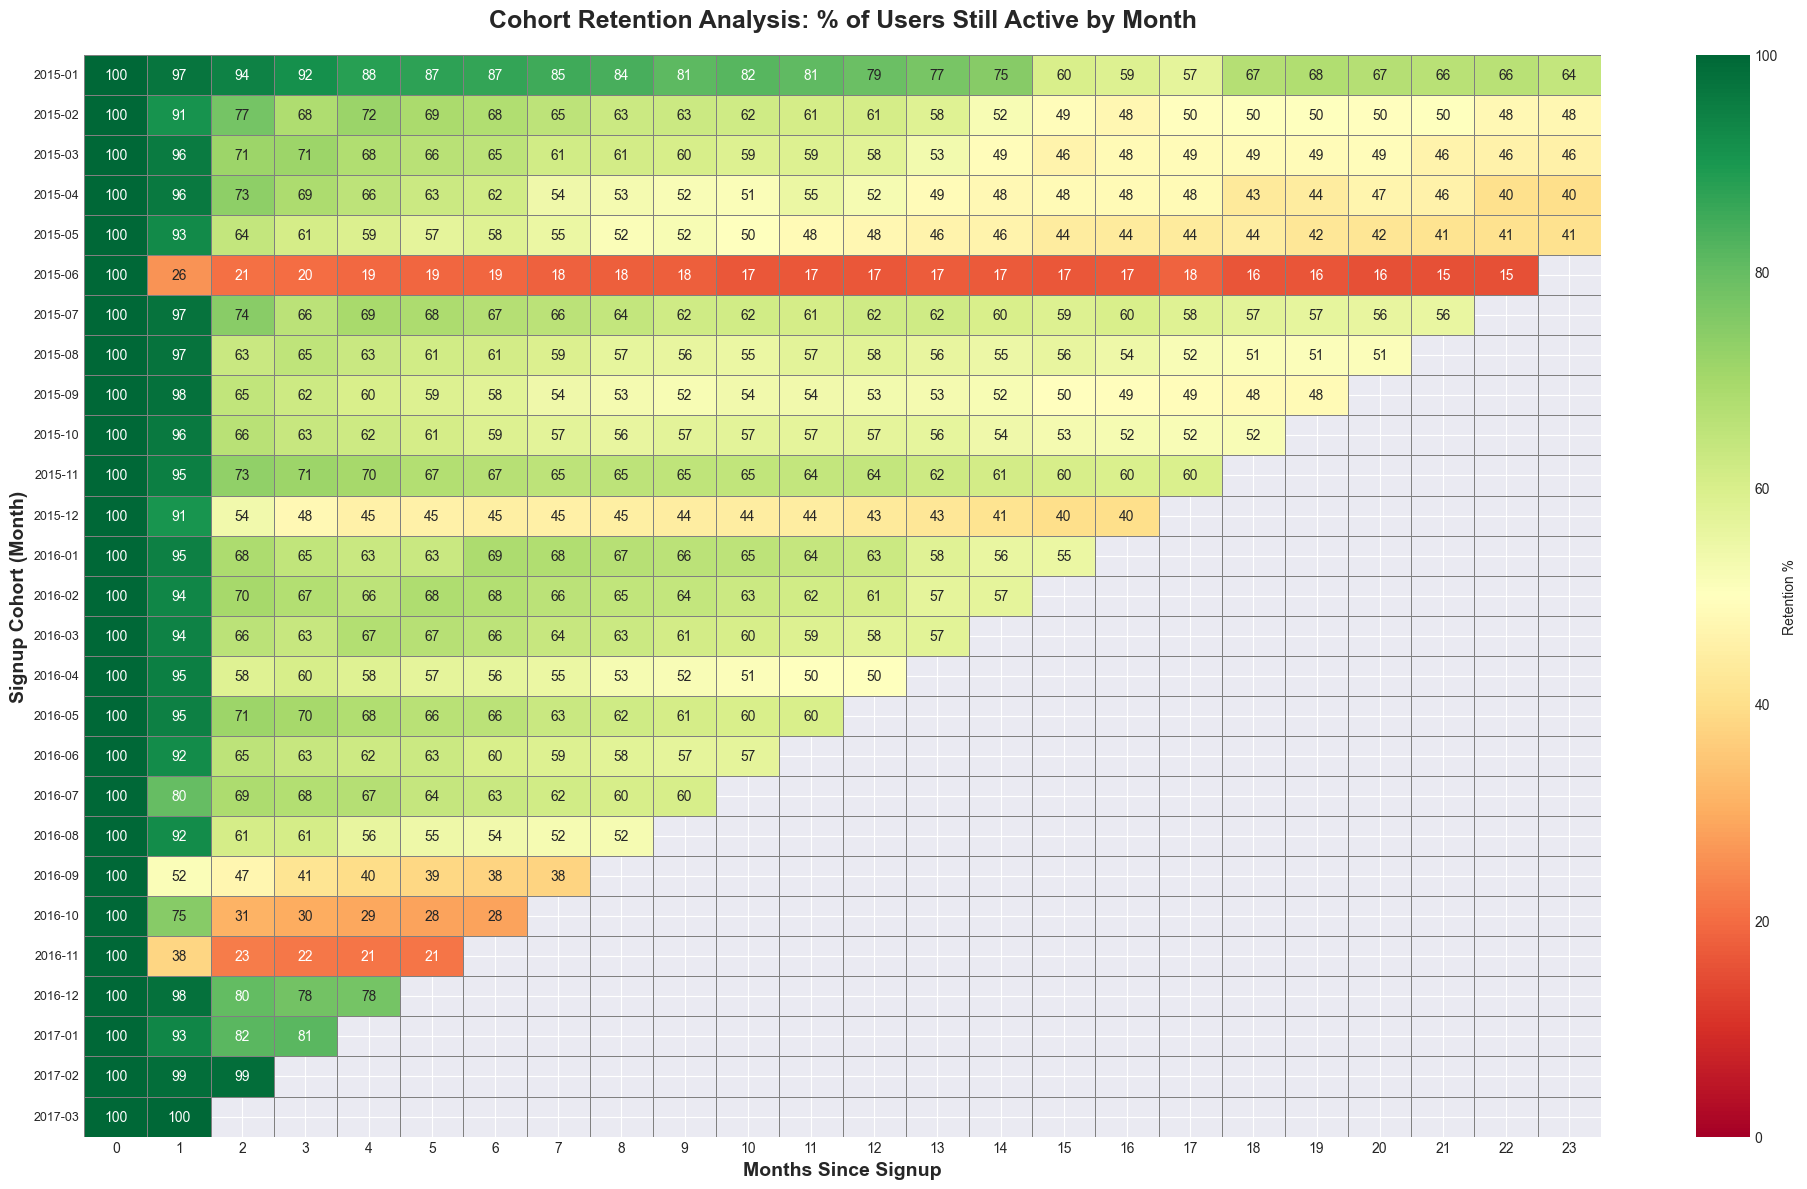


 Heatmap saved: cohort_retention_heatmap.png


In [16]:
# Prepare data
heatmap_data = cohort_retention_filtered.copy()
heatmap_data.index = heatmap_data.index.astype(str)

# Create figure
fig, ax = plt.subplots(figsize=(20, 12))

# Create heatmap
sns.heatmap(
    heatmap_data,
    annot=True,           # Show percentages
    fmt='.0f',            # No decimals
    cmap='RdYlGn',        # Red-Yellow-Green
    vmin=0,               # Min value
    vmax=100,             # Max value
    cbar_kws={'label': 'Retention %'},
    linewidths=0.5,       # Cell borders
    linecolor='gray',
    ax=ax
)

# Titles and labels
ax.set_title('Cohort Retention Analysis: % of Users Still Active by Month', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Months Since Signup', fontsize=14, fontweight='bold')
ax.set_ylabel('Signup Cohort (Month)', fontsize=14, fontweight='bold')

# Rotate labels
plt.yticks(rotation=0, fontsize=9)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Heatmap saved: cohort_retention_heatmap.png")

## Step 5 - Retention Curves by Cohort

Line Plots for Trends

**Better for:**
- Seeing retention curve shape
- Comparing specific cohorts
- Identifying outliers

In [ ]:
# Select a subset of cohorts for clarity
cohorts_to_plot = []
for year in range(2015, 2017):
    for month in [1, 4, 7, 10]:  # Q1, Q2, Q3, Q4
        cohort_str = f'{year}-{month:02d}'  # Create as sting
        
        if cohort_str in cohort_retention_filtered.index:  # Compare strings
            cohorts_to_plot.append(cohort_str)

print(f"   Selected {len(cohorts_to_plot)} cohorts:")
for c in cohorts_to_plot:
    size = cohort_sizes.get(c, 0)  # Use .get() to handle missing
    print(f"     {c} ({size:,.0f} users)")

   Selected 8 cohorts:
     2015-01 (549,166 users)
     2015-04 (38,975 users)
     2015-07 (63,055 users)
     2015-10 (87,988 users)
     2016-01 (89,032 users)
     2016-04 (38,950 users)
     2016-07 (64,710 users)
     2016-10 (98,973 users)


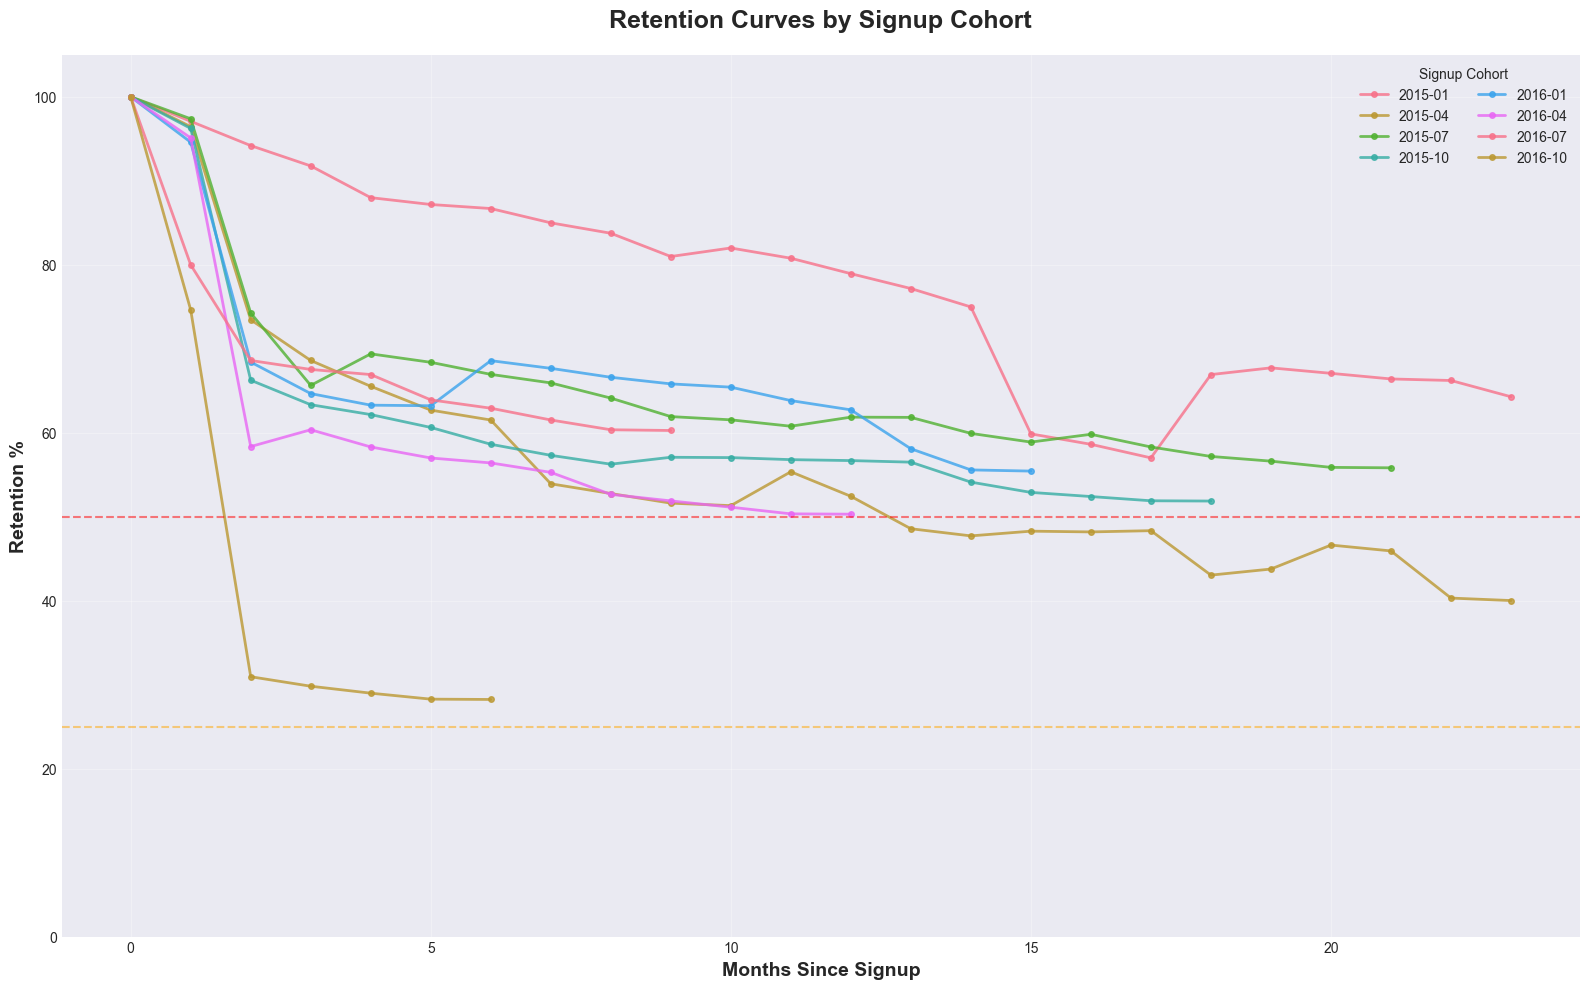


 Visualization saved: cohort_retention_curves.png


In [22]:
# Create retention curve visualization
fig, ax = plt.subplots(figsize=(16, 10))

# Plot each cohort
for cohort in cohorts_to_plot:
    cohort_data = cohort_retention_filtered.loc[cohort].dropna()
    ax.plot(
        cohort_data.index,
        cohort_data.values,
        marker='o',
        linewidth=2,
        markersize=4,
        label=str(cohort),
        alpha=0.8
    )

# Formatting
ax.set_title('Retention Curves by Signup Cohort', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Months Since Signup', fontsize=14, fontweight='bold')
ax.set_ylabel('Retention %', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
ax.legend(title='Signup Cohort', loc='upper right', fontsize=10, ncol=2)

# Add reference lines
ax.axhline(50, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='50% retention')
ax.axhline(25, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='25% retention')

plt.tight_layout()
plt.savefig('cohort_retention_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualization saved: cohort_retention_curves.png")

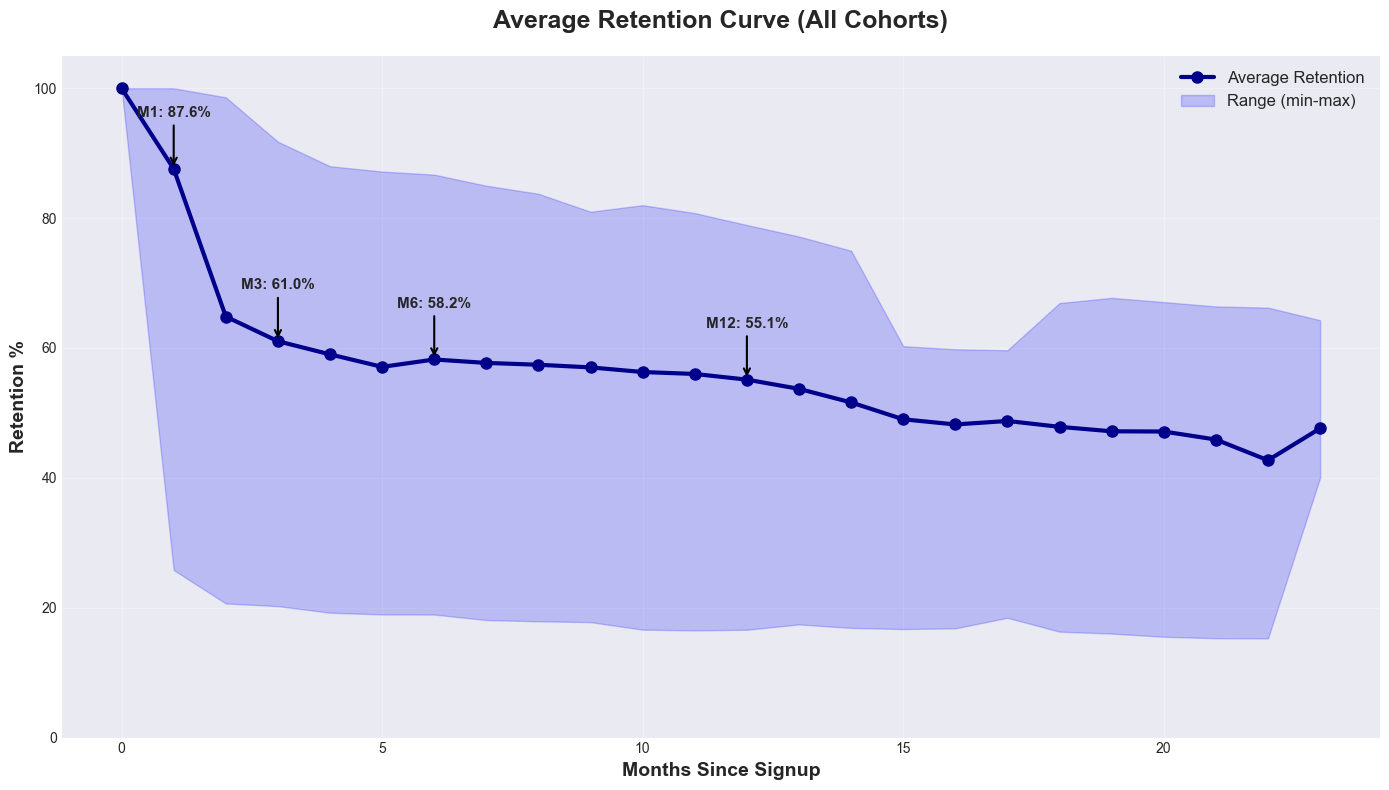


 Visualization saved: average_retention_curve.png

 Key retention milestones (average):
   Month  1:  87.6%
   Month  3:  61.0%
   Month  6:  58.2%
   Month 12:  55.1%
   Month 18:  47.9%


In [23]:
# Create average retention curve
avg_retention = cohort_retention_filtered.mean(axis=0)  # Calculate average retention across all cohorts

fig, ax = plt.subplots(figsize=(14, 8))

# Plot average
ax.plot(
    avg_retention.index[:24],  # First 24 months
    avg_retention.values[:24],
    marker='o',
    linewidth=3,
    markersize=8,
    color='darkblue',
    label='Average Retention'
)

# Add shaded range (min-max)
min_retention = cohort_retention_filtered.min(axis=0)
max_retention = cohort_retention_filtered.max(axis=0)
ax.fill_between(
    avg_retention.index[:24],
    min_retention.values[:24],
    max_retention.values[:24],
    alpha=0.2,
    color='blue',
    label='Range (min-max)'
)

# Annotations for key milestones
milestones = [1, 3, 6, 12]
for m in milestones:
    if m < len(avg_retention):
        retention_val = avg_retention.iloc[m]
        ax.annotate(
            f'M{m}: {retention_val:.1f}%',
            xy=(m, retention_val),
            xytext=(m, retention_val + 8),
            fontsize=11,
            fontweight='bold',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
        )

ax.set_title('Average Retention Curve (All Cohorts)', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Months Since Signup', fontsize=14, fontweight='bold')
ax.set_ylabel('Retention %', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('average_retention_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualization saved: average_retention_curve.png")

print("\n Key retention milestones (average):")
for m in [1, 3, 6, 12, 18, 24]:
    if m < len(avg_retention):
        print(f"   Month {m:2d}: {avg_retention.iloc[m]:5.1f}%")

## Step 6 - Month-N Retention Comparison

Cross-Cohort Benchmarking

**Question:** How has retention at specific milestones changed over time?

**Example:** Are 2016 cohorts retaining better at month-3 than 2015 cohorts?

In [24]:
# Select milestone months
milestone_months = [1, 3, 6, 12]

# Extract retention at each milestone
milestone_data = {}
for m in milestone_months:
    if m in cohort_retention_filtered.columns:
        milestone_data[f'Month_{m}'] = cohort_retention_filtered[m]

milestone_df = pd.DataFrame(milestone_data)
milestone_df.index = milestone_df.index.astype(str)

print(f"\nMilestone retention for {len(milestone_df)} cohorts:")
print(milestone_df.head(10))


Milestone retention for 27 cohorts:
                Month_1    Month_3    Month_6   Month_12
cohort_month                                            
2015-01       97.075383  91.764967  86.691456  78.936059
2015-02       90.812237  68.175154  67.682533  60.912912
2015-03       96.066615  71.366912  65.383363  57.610245
2015-04       96.436177  68.597819  61.508659  52.425914
2015-05       92.762153  60.906083  58.316365  47.655256
2015-06       25.800495  20.242411  18.947181  16.606247
2015-07       97.378479  65.631591  66.944731  61.850765
2015-08       97.387974  65.102418  61.290236  57.503675
2015-09       97.667151  62.493489  57.523507  53.367691
2015-10       96.231304  63.332500  58.622767  56.679320


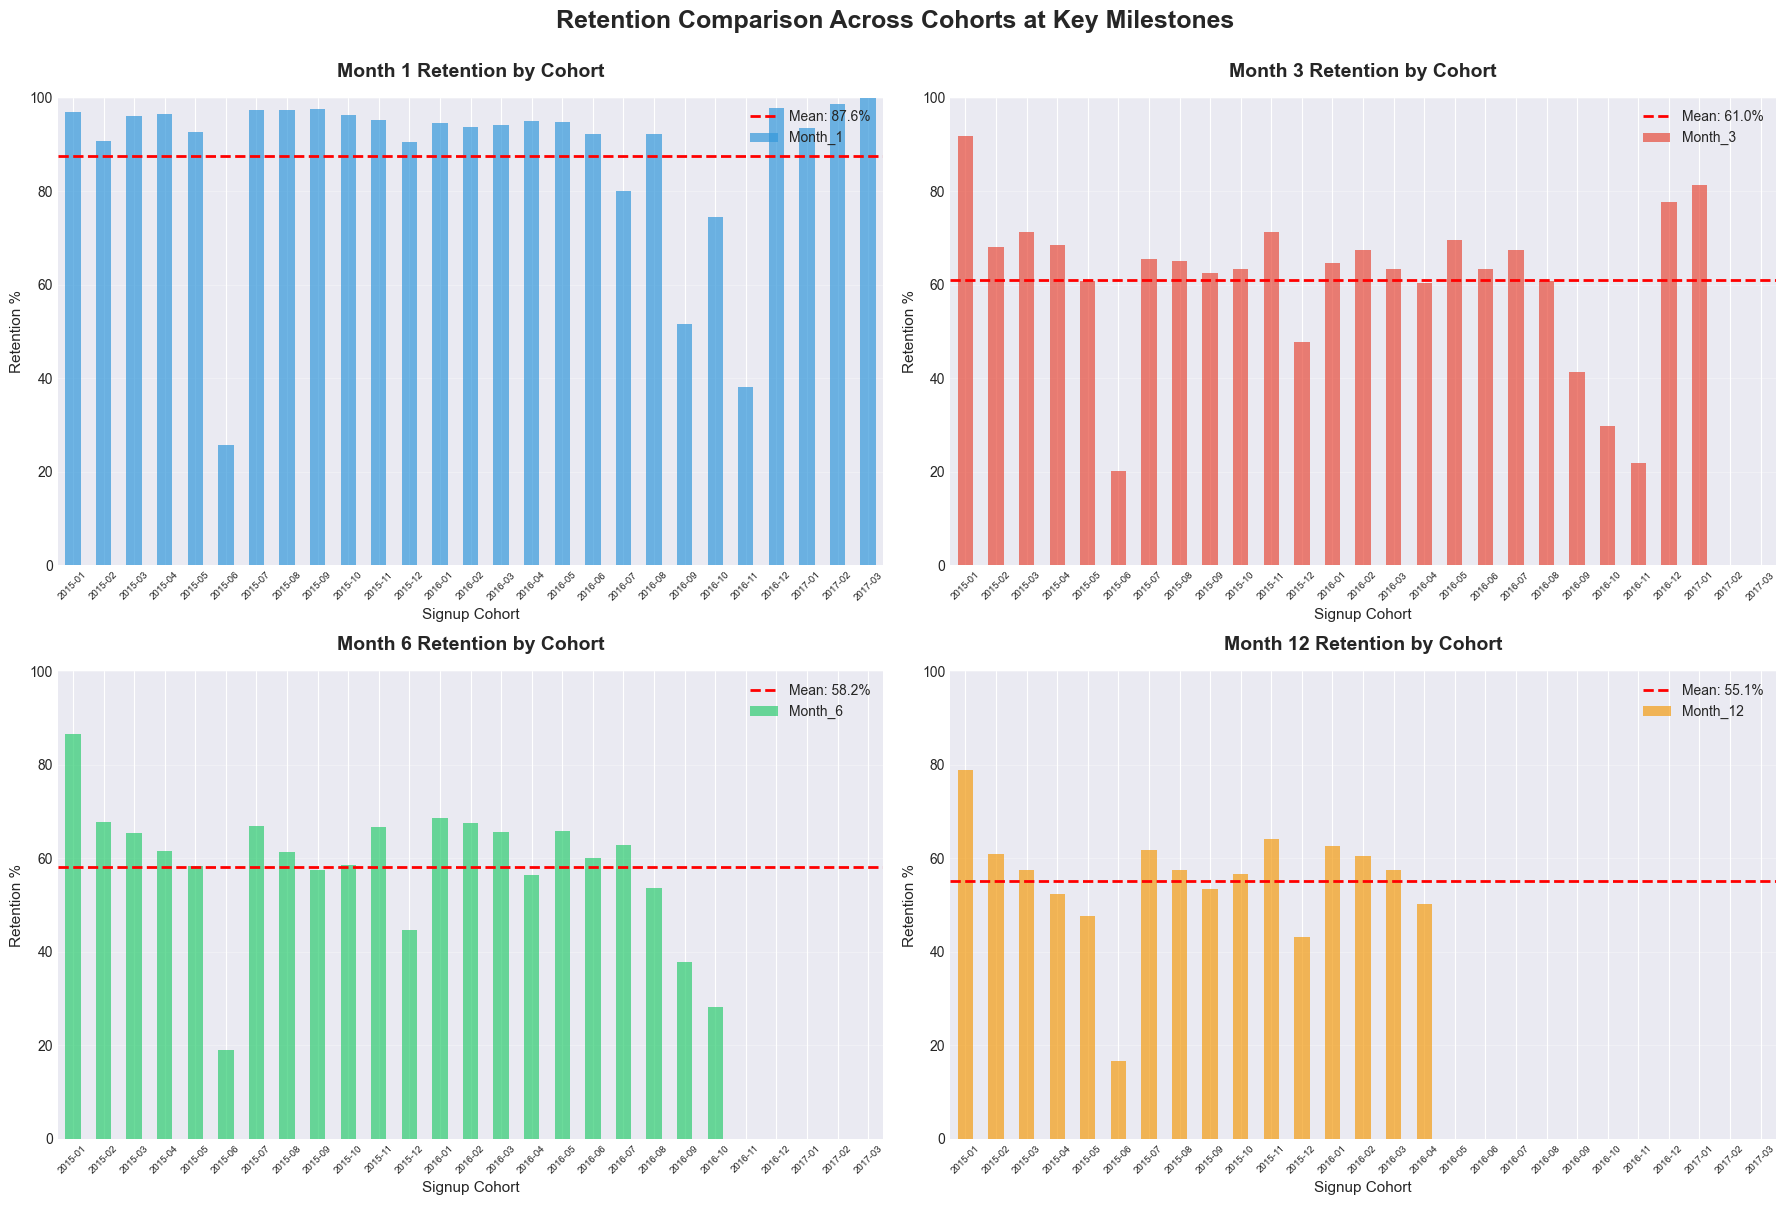


 Visualization saved: milestone_retention_comparison.png


In [25]:
# Creating milestone comparison charts

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (col, color) in enumerate(zip(milestone_df.columns, colors)):
    ax = axes[idx]
    
    # Plot
    milestone_df[col].plot(kind='bar', ax=ax, color=color, alpha=0.7)
    
    # Add mean line
    mean_val = milestone_df[col].mean()
    ax.axhline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}%')
    
    # Formatting
    month_num = col.split('_')[1]
    ax.set_title(f'Month {month_num} Retention by Cohort', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Signup Cohort', fontsize=11)
    ax.set_ylabel('Retention %', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_ylim(0, 100)

plt.suptitle('Retention Comparison Across Cohorts at Key Milestones', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('milestone_retention_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualization saved: milestone_retention_comparison.png")

In [26]:
# Retention statistics
for col in milestone_df.columns:
    month_num = col.split('_')[1]
    print(f"\n{col.replace('_', ' ')} Retention:")
    print(f"  Mean:   {milestone_df[col].mean():5.1f}%")
    print(f"  Median: {milestone_df[col].median():5.1f}%")
    print(f"  Std:    {milestone_df[col].std():5.1f}%")
    print(f"  Min:    {milestone_df[col].min():5.1f}% (worst cohort)")
    print(f"  Max:    {milestone_df[col].max():5.1f}% (best cohort)")
    
    # Best and worst cohorts
    best = milestone_df[col].idxmax()
    worst = milestone_df[col].idxmin()
    print(f"  Best cohort:  {best} ({milestone_df[col][best]:.1f}%)")
    print(f"  Worst cohort: {worst} ({milestone_df[col][worst]:.1f}%)")


Month 1 Retention:
  Mean:    87.6%
  Median:  94.6%
  Std:     18.8%
  Min:     25.8% (worst cohort)
  Max:    100.0% (best cohort)
  Best cohort:  2017-03 (100.0%)
  Worst cohort: 2015-06 (25.8%)

Month 3 Retention:
  Mean:    61.0%
  Median:  64.7%
  Std:     17.0%
  Min:     20.2% (worst cohort)
  Max:     91.8% (best cohort)
  Best cohort:  2015-01 (91.8%)
  Worst cohort: 2015-06 (20.2%)

Month 6 Retention:
  Mean:    58.2%
  Median:  61.4%
  Std:     14.7%
  Min:     18.9% (worst cohort)
  Max:     86.7% (best cohort)
  Best cohort:  2015-01 (86.7%)
  Worst cohort: 2015-06 (18.9%)

Month 12 Retention:
  Mean:    55.1%
  Median:  57.5%
  Std:     13.0%
  Min:     16.6% (worst cohort)
  Max:     78.9% (best cohort)
  Best cohort:  2015-01 (78.9%)
  Worst cohort: 2015-06 (16.6%)


## Step 7: Retention Trends Over Time

**Question:** Is retention improving for newer cohorts?

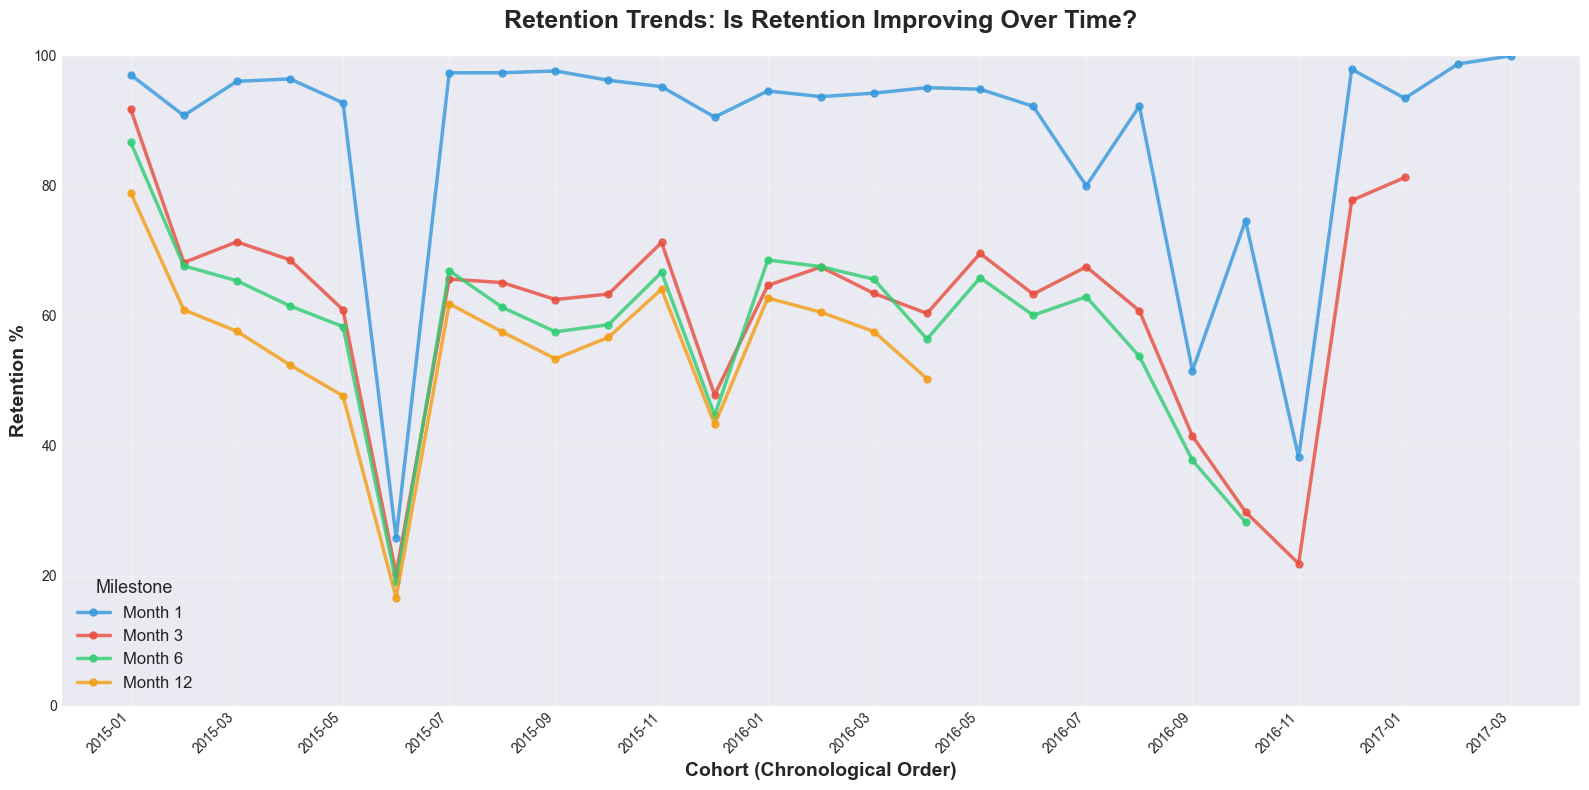


 Visualization saved: retention_trends.png


In [27]:
# Create trend visualization
fig, ax = plt.subplots(figsize=(16, 8))

for col, color in zip(milestone_df.columns, colors):
    month_num = col.split('_')[1]
    
    # Plot
    ax.plot(
        range(len(milestone_df)),
        milestone_df[col].values,
        marker='o',
        linewidth=2.5,
        markersize=5,
        color=color,
        label=f'Month {month_num}',
        alpha=0.8
    )

# Formatting
ax.set_title('Retention Trends: Is Retention Improving Over Time?', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Cohort (Chronological Order)', fontsize=14, fontweight='bold')
ax.set_ylabel('Retention %', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, len(milestone_df), max(1, len(milestone_df)//10)))
ax.set_xticklabels(
    [milestone_df.index[i] for i in range(0, len(milestone_df), max(1, len(milestone_df)//10))],
    rotation=45,
    ha='right'
)
ax.grid(alpha=0.3)
ax.legend(title='Milestone', fontsize=12, title_fontsize=13)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('retention_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualization saved: retention_trends.png")

In [29]:
# Compare first half vs second half of cohorts
midpoint = len(milestone_df) // 2

early_cohorts = milestone_df.iloc[:midpoint]
recent_cohorts = milestone_df.iloc[midpoint:]

print(f"\nEarly cohorts: {early_cohorts.index[0]} to {early_cohorts.index[-1]}")
print(f"Recent cohorts: {recent_cohorts.index[0]} to {recent_cohorts.index[-1]}")

print("\nRetention comparison:")
print(f"{'Milestone':<15} {'Early Mean':<12} {'Recent Mean':<13} {'Change':<10} {'Trend'}")
print("-" * 65)

for col in milestone_df.columns:
    early_mean = early_cohorts[col].mean()
    recent_mean = recent_cohorts[col].mean()
    change = recent_mean - early_mean
    trend = ' Improving' if change > 1 else ' Declining' if change < -1 else ' Stable'
    
    print(f"{col:<15} {early_mean:>10.1f}%  {recent_mean:>11.1f}%  {change:>+8.1f}%  {trend}")


Early cohorts: 2015-01 to 2016-01
Recent cohorts: 2016-02 to 2017-03

Retention comparison:
Milestone       Early Mean   Recent Mean   Change     Trend
-----------------------------------------------------------------
Month_1               89.8%         85.5%      -4.4%   Declining
Month_3               63.2%         58.7%      -4.5%   Declining
Month_6               60.2%         55.3%      -4.9%   Declining
Month_12              54.9%         56.1%      +1.2%   Improving


## Step 8 - Churn Timing Analysis

When Do Users Leave?

**Calculate:** How many users churn in each month?

In [30]:
# Calculate churn as difference between consecutive months
cohort_churn = -cohort_retention_filtered.diff(axis=1)

# First month is special (churn from 100%)
cohort_churn[0] = 100 - cohort_retention_filtered[0]

# Average churn by month
avg_churn = cohort_churn.mean(axis=0)

print("\n   Average churn % by month:")
print("   Month  Churn%  Cumulative")
print("   " + "-"*30)
cumulative = 0
for m in range(min(12, len(avg_churn))):
    cumulative += avg_churn.iloc[m]
    print(f"     {m:2d}    {avg_churn.iloc[m]:5.1f}%    {cumulative:5.1f}%")


   Average churn % by month:
   Month  Churn%  Cumulative
   ------------------------------
      0      0.0%      0.0%
      1     12.4%     12.4%
      2     22.3%     34.7%
      3      2.4%     37.1%
      4      1.2%     38.3%
      5      1.1%     39.4%
      6      0.5%     39.9%
      7      2.0%     41.9%
      8      1.3%     43.2%
      9      0.7%     43.8%
     10      0.5%     44.4%
     11      0.3%     44.6%


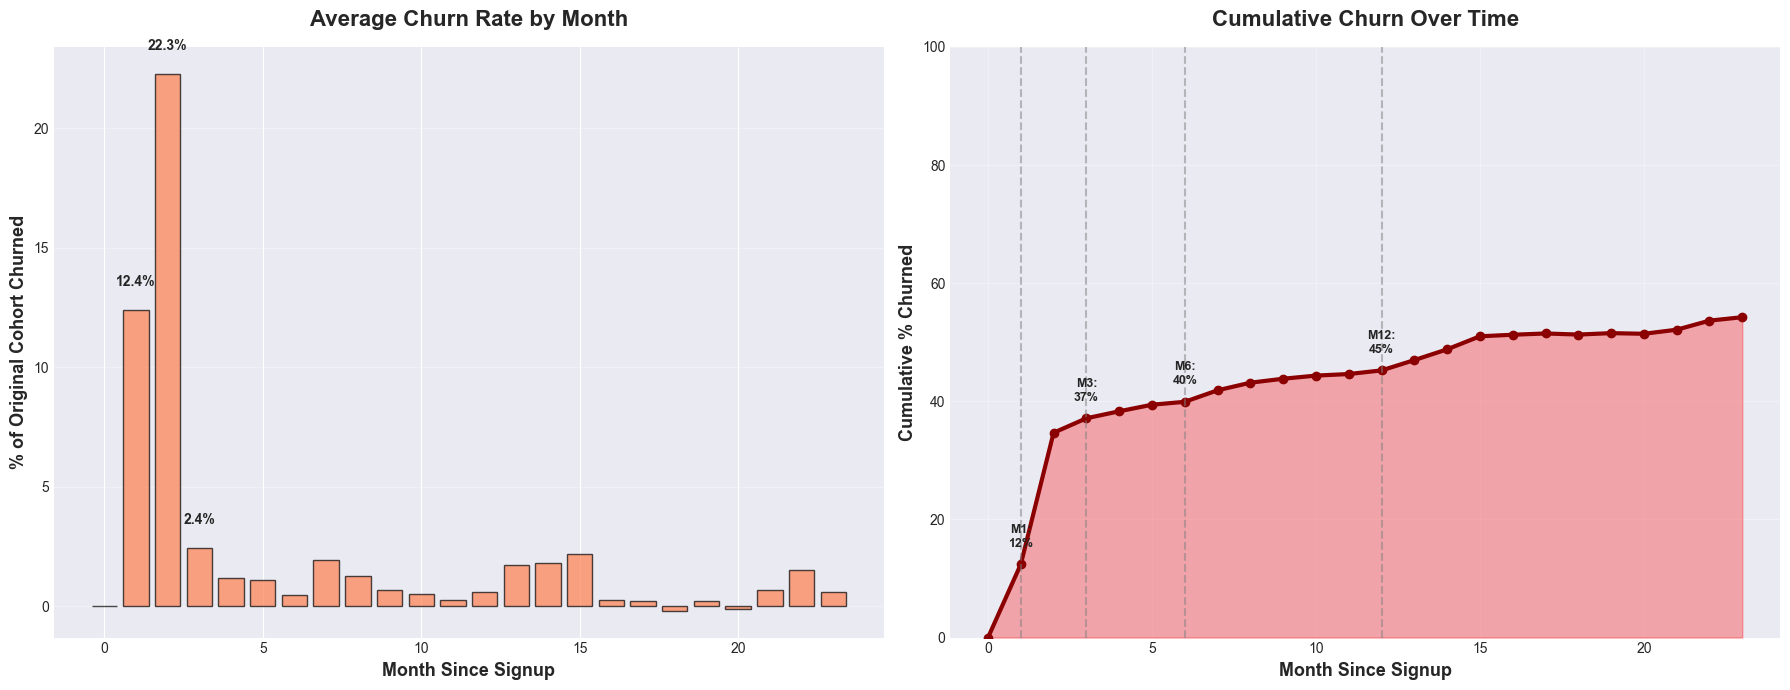


 Visualization saved: churn_timing_analysis.png


In [31]:
# Visualise churn timing

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot monthly churn rate
months = avg_churn.index[:24]
values = avg_churn.values[:24]

ax1.bar(months, values, color='coral', alpha=0.7, edgecolor='black')
ax1.set_title('Average Churn Rate by Month', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Month Since Signup', fontsize=13, fontweight='bold')
ax1.set_ylabel('% of Original Cohort Churned', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Annotate highest churn months
top_churn_months = np.argsort(values)[-3:][::-1]
for m in top_churn_months:
    ax1.text(months[m], values[m] + 1, f'{values[m]:.1f}%', 
             ha='center', fontsize=10, fontweight='bold')

# Plot cumulative churn
cumulative_churn = avg_churn.cumsum()[:24]

ax2.plot(months, cumulative_churn, marker='o', linewidth=3, 
         markersize=6, color='darkred', label='Cumulative Churn')
ax2.fill_between(months, 0, cumulative_churn, alpha=0.3, color='red')

ax2.set_title('Cumulative Churn Over Time', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Month Since Signup', fontsize=13, fontweight='bold')
ax2.set_ylabel('Cumulative % Churned', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 100)

# Add milestone markers
for m in [1, 3, 6, 12]:
    if m < len(cumulative_churn):
        val = cumulative_churn.iloc[m]
        ax2.axvline(m, color='gray', linestyle='--', alpha=0.5)
        ax2.text(m, val + 3, f'M{m}:\n{val:.0f}%', 
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_timing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualization saved: churn_timing_analysis.png")